### Old Data Reader

I replaced it with a new function that leverages the "chunks" property of pd.read_csv since the large dataset is 3GB and the kernel kept dying.

The way it works now is that pandas does not attempt to read the whole file at once.

In [1]:
# data is your csv data and variable is a boolean to determine
# whether you are passing in your X (0) or y (1) data
def data_conversion_csv(data, variable):
    # converts from pandas.core.series.Series to a list
    empty_list = []

    # if reading the X variable, reshape it into 20x3 format
    if not variable:     
        data = data.tolist()
     
        # removes the new line characters
        data = [entry.replace('\n', '').replace('[', '').replace(']', '') for entry in data]

        for entry in data:
            numbers = entry.replace('.', '').split()
            float_numbers = [float(num) for num in numbers]
            tensor_data = torch.tensor(float_numbers, dtype=torch.float64)
            final_tensor = tensor_data.view(20, 3)
            empty_list.append(final_tensor)
    
    # else if you are reading the y variable
    else:
        for entry in data:
            final_tensor = torch.tensor(eval(entry))
            empty_list.append(final_tensor)
    return empty_list


X_data, y_data = [], []

if dataset_choice == 0:
    # larger dataset with 
    X_data = data_conversion_csv(pd.read_csv(big_dataset)['data_id'], False)
    y_data = data_conversion_csv(pd.read_csv(big_dataset)['state_id'], True)
if dataset_choice == 1:
    X_data = data_conversion_csv(pd.read_csv(medium_dataset)['data_id'], False)
    y_data = data_conversion_csv(pd.read_csv(medium_dataset)['state_id'], True)
if dataset_choice == 2:
    # smaller dataset with ~500 points
    X_data = torch.load('training_data/X_data.pt')
    y_data = torch.load('training_data/y_data.pt')

len(X_data)

NameError: name 'dataset_choice' is not defined

# Notebook 1

Work on model save and reload.
Saves whatever information is needed to reload.
Saves path and makes it so you are able to return your model.
Check if the model comes with builtin model save functions.
You can use Pickle, but it takes a LOT of space. Olivia suggested joblib.

In [6]:
# imports dependencies
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from difflogic import LogicLayer, GroupSum
import os
import sys

### Environment Check

In [1]:
!echo $SLURM_JOB_ID

33678593


In [2]:
import pkg_resources
sorted_packages = sorted(pkg_resources.working_set, key=lambda x: x.project_name.lower())
for dist in sorted_packages:
    print(dist.project_name, dist.version)

albumentations 1.4.4
annotated-types 0.6.0
anyio 4.3.0
argon2-cffi 23.1.0
argon2-cffi-bindings 21.2.0
arrow 1.3.0
asttokens 2.4.1
async-lru 2.0.4
attrs 23.2.0
audiomentations 0.35.0
audioread 3.0.1
Babel 2.14.0
beautifulsoup4 4.12.3
bleach 6.1.0
Brotli 1.1.0
cached-property 1.5.2
certifi 2024.2.2
cffi 1.16.0
charset-normalizer 3.3.2
cloudpickle 3.0.0
comm 0.2.2
contourpy 1.2.1
cycler 0.12.1
debugpy 1.8.1
decorator 5.1.1
defusedxml 0.7.1
difflogic 0.1.0
entrypoints 0.4
exceptiongroup 1.2.0
executing 2.0.1
Farama-Notifications 0.0.4
fastjsonschema 2.19.1
fonttools 4.51.0
fqdn 1.5.1
gym 0.26.2
gym-notices 0.0.8
gymnasium 0.29.1
h11 0.14.0
h2 4.1.0
hpack 4.0.0
httpcore 1.0.5
httpx 0.27.0
hyperframe 6.0.1
idna 3.7
imageio 2.34.1
importlib-metadata 7.1.0
importlib-resources 6.4.0
ipykernel 6.29.3
ipython 8.18.1
ipywidgets 8.1.3
isoduration 20.11.0
jedi 0.19.1
jinja2 3.1.4
joblib 1.4.0
json5 0.9.25
jsonpointer 2.4
jsonschema 4.22.0
jsonschema-specifications 2023.12.1
jupyter 1.0.0
jupyter-cli

/scratch/local/33678593/ipykernel_114747/1602474190.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [7]:
# this should output the Python path you've set in kernel.json
import sys
print(sys.executable)

/blue/woodard/mkunzlermaldaner/project/SKEPTIC/schoolhouse_ex/testing_env/bin/python


In [8]:
# yields the correct pathing to the notebook's dependencies
import sys
!{sys.executable} -m pip list

Package                   Version
------------------------- --------------
albumentations            1.4.4
annotated-types           0.6.0
anyio                     4.3.0
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
arrow                     1.3.0
asttokens                 2.4.1
async-lru                 2.0.4
attrs                     23.2.0
audiomentations           0.35.0
audioread                 3.0.1
Babel                     2.14.0
beautifulsoup4            4.12.3
bleach                    6.1.0
Brotli                    1.1.0
cached-property           1.5.2
certifi                   2024.2.2
cffi                      1.16.0
charset-normalizer        3.3.2
cloudpickle               3.0.0
comm                      0.2.2
contourpy                 1.2.1
cycler                    0.12.1
debugpy                   1.8.1
decorator                 5.1.1
defusedxml                0.7.1
difflogic                 0.1.0
entrypoints               0.4
exceptiongroup      

In [10]:
# yields the wrong dependencies for some reason (?)
# showing global dependencies or something, doesnt affect anything but I am just curious.
!pip list

Package                        Version     Editable project location
------------------------------ ----------- ------------------------------------------------------------
aiofiles                       22.1.0
aiosqlite                      0.18.0
alembic                        1.10.3
anyio                          3.6.2
argon2-cffi                    21.3.0
argon2-cffi-bindings           21.2.0
arrow                          1.2.3
asttokens                      2.2.1
async-generator                1.10
async-lru                      2.0.2
attrs                          22.2.0
Babel                          2.12.1
backcall                       0.2.0
backports.functools-lru-cache  1.6.4
batchspawner                   1.2.0
beautifulsoup4                 4.12.2
bleach                         6.0.0
blinker                        1.6.2
brotlipy                       0.7.0
certifi                        2023.11.17
certipy                        0.1.3
cffi                           1.15.1


### Skeptic

In [7]:
# sets skeptic path
shared_path = "/blue/woodard/share/skeptical_beings/schoolhouse/"
sys.path.append("/blue/woodard/share/skeptical_beings/schoolhouse/") 
from schoolhouse_gym_stable import * 

In [8]:
xml_file_path = shared_path + "SchoolHouse_29.graphml" 
data_folder_path = shared_path + "./" 
#image_folder_path = shared_path + "image_files.txt"
#audio_folder_path = shared_path + "audio_files.txt"
env = CustomMDPEnvironment(xml_file_path, data_folder_path)

/blue/woodard/mkunzlermaldaner/project/SKEPTIC/schoolhouse_ex/testing_env/lib/python3.9/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [35]:
X_data = []
y_data = []
extra_data = []
for _ in range(100):
    xse_data = env.get_xse_data()
    X, y, extra = xse_data[0], xse_data[1], xse_data[2:]
    # X.shape is (20,3)

    # converts to tensor for better computation
    X = torch.tensor(X)
    y = torch.tensor(y)
    
    # appends to list
    X_data.append(X)
    y_data.append(y)
    extra_data.append(extra)
    
    # add a function call to randomly change the skeptic stuff
    # so not all data samples are the same

In [21]:
# example dataset with multi-class targets
class CustomDataset(Dataset):
    def __init__(self, size=100, num_classes=[12, 12, 12]):  # where num_classes is range for each
        low, high = 0, 10
        
        # empty matrix to store each markov decision process "run"
        data_matrix = []
        for _ in range(size):
            temp_data = torch.randint(low, high, (20, 3)) 
            data_matrix.append(temp_data)
            
        # assigns filled matrix and sets random labels for the data     
        self.data = data_matrix
        self.labels = torch.stack([torch.randint(0, k, (size,)) for k in num_classes], dim=1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

mydata = CustomDataset()
mydata.data[0], mydata.labels[0]

(tensor([[9, 9, 7],
         [6, 7, 1],
         [0, 9, 7],
         [8, 6, 5],
         [4, 7, 3],
         [8, 7, 0],
         [4, 5, 6],
         [7, 1, 1],
         [2, 4, 1],
         [4, 9, 2],
         [1, 5, 3],
         [9, 2, 3],
         [5, 3, 1],
         [0, 5, 2],
         [7, 5, 4],
         [1, 5, 7],
         [7, 1, 8],
         [2, 6, 6],
         [1, 0, 0],
         [5, 7, 6]]),
 tensor([2, 9, 3]))

In [14]:
# example dataset with multi-class targets
class CustomDataset(Dataset):
    def __init__(self, size=100, num_classes=[12, 12, 12]):  # where num_classes is range for each
        self.data = torch.randint(size, (20, 3)) 
        # randomly generates labels according to class range for each dimension
        self.labels = torch.stack([torch.randint(0, k, (size,)) for k in num_classes], dim=1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# DiffLogic model
class DiffLogicNet(torch.nn.Module):
    def __init__(self, num_classes):
        super(DiffLogicNet, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.logic_layer1 = LogicLayer(60, 120, device='cuda')  
        self.logic_layer2 = LogicLayer(120, 240, device='cuda')
        self.logic_layer3 = LogicLayer(240, 480, device='cuda')
        self.logic_layer4 = LogicLayer(480, 960, device='cuda')
        self.logic_layer5 = LogicLayer(960, 1920, device='cuda')
        
        self.group_sum1 = GroupSum(k=num_classes[0], tau=10, device='cuda')
        self.group_sum2 = GroupSum(k=num_classes[1], tau=10, device='cuda')
        self.group_sum3 = GroupSum(k=num_classes[2], tau=10, device='cuda')

    def forward(self, x):
        x = self.flatten(x)
        x = self.logic_layer1(x)
        x = self.logic_layer2(x)
        x = self.logic_layer3(x)
        x = self.logic_layer4(x)
        x = self.logic_layer5(x)
        out1 = self.group_sum1(x)
        out2 = self.group_sum2(x)
        out3 = self.group_sum3(x)
        return torch.cat([out1, out2, out3], dim=1)

# custom loss for handling multiple categorical outputs
def custom_loss(outputs, labels):
    loss_fn = torch.nn.CrossEntropyLoss()
    loss1 = loss_fn(outputs[:, 0:12], labels[:, 0])
    loss2 = loss_fn(outputs[:, 12:24], labels[:, 1])
    loss3 = loss_fn(outputs[:, 24:], labels[:, 2])
    return loss1 + loss2 + loss3

# training
def train_model(model, criterion, optimizer, train_loader, num_epochs=10):
    model.train()
    for epoch in tqdm(range(num_epochs)):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

# function to compute accuracy for multi-class categorical outputs
def evaluate_model(model, data_loader):
    model.eval()
    total_correct1, total_correct2, total_correct3 = 0, 0, 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            outputs = model(inputs)
            
            # Correct handling of splits based on the exact output from each GroupSum
            predicted1 = outputs[:, 0:12].argmax(1)
            predicted2 = outputs[:, 12:24].argmax(1)
            predicted3 = outputs[:, 24:].argmax(1)  # Ensure this index matches output from GroupSum3

            correct1 = (predicted1 == labels[:, 0])
            correct2 = (predicted2 == labels[:, 1])
            correct3 = (predicted3 == labels[:, 2])

            total_correct1 += correct1.sum().item()
            total_correct2 += correct2.sum().item()
            total_correct3 += correct3.sum().item()
            
            total += labels.size(0)
    
    accuracy1 = total_correct1 / total
    accuracy2 = total_correct2 / total
    accuracy3 = total_correct3 / total
    print(f'Accuracy for output 1: {accuracy1:.4f}')
    print(f'Accuracy for output 2: {accuracy2:.4f}')
    print(f'Accuracy for output 3: {accuracy3:.4f}')

# main function to tie it all together
def main():
    num_classes = [12, 12, 12]  # Example: Adjust based on actual class sizes for each output dimension
    dataset = CustomDataset(num_classes=num_classes)
    train_loader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = DiffLogicNet(num_classes=num_classes).to('cuda')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    train_model(model, custom_loss, optimizer, train_loader, num_epochs=50)
    evaluate_model(model, train_loader)

if __name__ == '__main__':
    main()

  0%|          | 0/50 [00:00<?, ?it/s]


AssertionError: (torch.Size([3, 10]), 60)

### DiffLogic

In [18]:
from difflogic import LogicLayer, GroupSum
import torch.nn.functional as F
import torch

##### Layer definitions

In [23]:
layer1 = LogicLayer(
    in_dim=60,              # number of inputs
    out_dim=120,            # number of outputs
    device='cuda',          # the device (cuda / cpu)
    implementation='cuda',  # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',   # the method for the random initialization of the connections
    grad_factor=2,          # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)

layer2 = LogicLayer(
    in_dim=120,             # number of inputs
    out_dim=240,            # number of outputs
    device='cuda',          # the device (cuda / cpu)
    implementation='cuda',  # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',   # the method for the random initialization of the connections
    grad_factor=2,          # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)

layer3 = LogicLayer(
    in_dim=240,             # number of inputs
    out_dim=480,            # number of outputs
    device='cuda',          # the device (cuda / cpu)
    implementation='cuda',  # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',   # the method for the random initialization of the connections
    grad_factor=2,          # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)

layer4 = LogicLayer(
    in_dim=480,             # number of inputs
    out_dim=960,            # number of outputs
    device='cuda',          # the device (cuda / cpu)
    implementation='cuda',  # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',   # the method for the random initialization of the connections
    grad_factor=2,          # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)

layer5 = LogicLayer(
    in_dim=960,             # number of inputs
    out_dim=1920,           # number of outputs
    device='cuda',          # the device (cuda / cpu)
    implementation='cuda',  # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',   # the method for the random initialization of the connections
    grad_factor=2,          # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)

layer6 = LogicLayer(
    in_dim=1920,            # number of inputs
    out_dim=1920,           # number of outputs
    device='cuda',          # the device (cuda / cpu)
    implementation='cuda',  # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',   # the method for the random initialization of the connections
    grad_factor=2,          # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)

#####

In [29]:
def skeptic_model_test():
    # defining model architecture
    model = torch.nn.Sequential(
        torch.nn.Flatten(),
        layer1,
        layer2,
        layer3,
        layer4,
        layer5,
        layer6,
        layer6,
        layer6,
        layer6,
        GroupSum(k=3, tau=30)
    )

    # use CUDA if available (it better be available after all this work lol)
    if torch.cuda.is_available():
        model = model.cuda()

    # create dummy data with batch size = 1 and input features = 784
    input_data = torch.rand((1, 20, 3))
    
    # move data to CUDA if possible
    if torch.cuda.is_available():
        input_data = input_data.cuda()

    # forward pass through the model
    output = model(input_data)

    # prints and check if output dimensions are correct
    print("Output dimensions:", output.shape)
    print("Output data:", output)
    assert output.shape == (1,3), "Output shape is incorrect."
    print("Test passed!")

skeptic_model_test()

Output dimensions: torch.Size([1, 3])
Output data: tensor([[10.6178, 10.5600, 10.6524]], device='cuda:0', grad_fn=<DivBackward0>)
Test passed!


### All Callable Instances

In [27]:
# env.action_space
env.action_space

Box(0.0, 1.0, (), float32)

In [34]:
env.action_space
env.amap
env.audio_file_paths
env.audioform
env.current_energy
env.current_state_id
env.current_step
env.data_folder_path
env.example_text_length
env.image_file_paths
env.imap
env.last_action
env.lose_threshold
env.max_steps
env.mdp
env.memory
env.metadata
env.notional_state_list
env.np_random
env.num_text_samples
env.observation_space
env.possible_actions
env.range
env.render_mode
env.reward_method
env.reward_range
env.spec
env.starting_energy
env.starting_state
env.steps_until_reward_reset
env.tmap
env.transform
env.unwrapped
env.win_threshold
env.xml_file_path

'/blue/woodard/share/skeptical_beings/schoolhouse/SchoolHouse_29.graphml'

# Notebook 2

In [2]:
# imports dependencies
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from difflogic import LogicLayer, GroupSum
import os
import sys
# sets skeptic path
shared_path = "/blue/woodard/share/skeptical_beings/schoolhouse/"
sys.path.append("/blue/woodard/share/skeptical_beings/schoolhouse/") 
from schoolhouse_gym_stable import * 

In [4]:
xml_file_path = shared_path + "SchoolHouse_29.graphml" 
data_folder_path = shared_path + "./" 
env = CustomMDPEnvironment(xml_file_path, data_folder_path)

/blue/woodard/mkunzlermaldaner/project/SKEPTIC/schoolhouse_ex/testing_env/lib/python3.9/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [5]:
# returns current state, starting is '0'
env.current_state_id

'0'

In [10]:
# possible actions the agent may take
env.get_actions(env.current_state_id) 

(['Move up hall ', 'Enter principal office'], 2, array([0. , 0.5, 1. ]))

In [159]:
# simple dataset generation

In [156]:
X_data = []
y_data = []
extra_data = []
for _ in range(50):

    # function call to randomly change the skeptic stuff    
    stepping_through_skeptic()
    xse_data = env.get_xse_data()
    
    X, y, extra = xse_data[0], xse_data[1], xse_data[2:]
    # X.shape is (20,3)

    # converts to tensor for better computation
    X = torch.tensor(X)
    y = torch.tensor(y)
    
    # appends to list
    X_data.append(X)
    y_data.append(y)
    extra_data.append(extra)

In [154]:
# function that randomly traverses environment till reaches a dead end, then returns the data
def stepping_through_skeptic():
    done = False
    env.reset()
    while done is False:

        # gets the possible future actions given the current node state
        actions, num_actions, partitioned_range = env.get_actions(env.current_state_id)

        # randomly picks one of the possible actions
        action_index = np.random.choice(num_actions)  
        action = actions[action_index]

        # ensures you are in the desired partitioned_range 
        action_val = (action_index + 0.5) / num_actions  

        # take a step to the next state and checks new actions
        observation, reward, terminated, truncated, info, done = env.step(action_val)

        #!!! "done" is still returning False despite terminated being True
        # I thought done worked as an OR(terminated, truncated) statement
        # temporary solution. though currently only terminated ends the run, maybe add a specific N iterations before truncated force exits?
        done = terminated or truncated
    
# env.get_actions(env.current_state_id) 
# env.get_xse_data()

In [158]:
X_data[15], y_data[15]

(tensor([[0., 0., 1.],
         [1., 2., 2.],
         [1., 2., 2.],
         [2., 1., 1.],
         [0., 1., 1.],
         [2., 2., 2.],
         [3., 2., 2.],
         [3., 1., 1.],
         [0., 1., 1.],
         [2., 4., 4.],
         [3., 4., 4.],
         [3., 4., 4.],
         [0., 0., 1.],
         [2., 4., 1.],
         [3., 4., 3.],
         [3., 4., 3.],
         [1., 0., 1.],
         [2., 4., 2.],
         [3., 4., 2.],
         [3., 4., 1.]], dtype=torch.float64),
 tensor([2, 1, 1]))

In [ ]:
env.action_space
env.amap
env.audio_file_paths
env.audioform
env.current_energy
env.current_state_id
env.current_step
env.data_folder_path
env.example_text_length
env.image_file_paths
env.imap
env.last_action
env.lose_threshold
env.max_steps
env.mdp
env.memory
env.metadata
env.notional_state_list
env.np_random
env.num_text_samples
env.observation_space
env.possible_actions
env.range
env.render_mode
env.reward_method
env.reward_range
env.spec
env.starting_energy
env.starting_state
env.steps_until_reward_reset
env.tmap
env.transform
env.unwrapped
env.win_threshold
env.xml_file_path

# Notebook 3

use jupyter notebook for developing w jupyter notebook for difflogic
 -- easier to visualize
 -- not designed to work w sbatch
 -- not gonna work w many many jobs
 -- take ideas used in design for jupyter notebook to create batch scripts
 -- use jupyter for maybe 1 epoch (small things)                                                        
 -- literally just to see if it works, not used for long training stuff


 -- run github difflogic examples in here to make sure it works
 -- create model that takes in schoolhouse data stuff and gets a meaningful output (?)
                                 -- sample of data IDs -> difflogic model -> output stuff
                                         -- how it will be structured

 -- LOGIN NODE: 16 cores 10 minutes and 64gb AS LONG as they dont impact other users                                                                    

---

## Skeptic

In [1]:
import sys
shared_path = "/blue/woodard/share/skeptical_beings/schoolhouse/"
sys.path.append("/blue/woodard/share/skeptical_beings/schoolhouse/") 
from schoolhouse_gym_stable import * 
xml_file_path = shared_path + "SchoolHouse_29.graphml" 
data_folder_path = shared_path + "./" 
env = CustomMDPEnvironment(xml_file_path, data_folder_path)

/blue/woodard/mkunzlermaldaner/project/SKEPTIC/schoolhouse_ex/testing_env/lib/python3.9/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [2]:
# stepping through your environment
action_val = 0.5 # (value between [0-1], could select randomly to generate a dataset) 
observation, reward, terminated, truncated, info, done = env.step(action_val)

In [3]:
# getting training data for the algorithm
xse_data = env.get_xse_data()
xkr_data = env.get_xkr_data()

In [4]:
# test the state embedding
true_id              = np.array([(3,2,5), (1,2,3), (3,4,3), (1,2,3)])
predicted_id         = np.array([(3,2,5), (1,2,3), (3,4,3), (1,4,4)])
probability          =          [      1,     0.5,       1,       1]
xse_score = env.test_notional_state_id(true_id, predicted_id, probability)

In [5]:
# test knowledge representation
true_curr_state      = [(1,1,1), (1,1,1)]
true_actions         = [    0.5,     0.5]
true_next_state      = [(1,1,2), (1,1,2)]
predicted_next_state = [(1,1,1), (1,1,2)]
probability          = [    0.5,     0.5]
reward               = [      1,     0.5]
xkr_score = env.test_notional_next_state_id(true_curr_state, true_actions, true_next_state, predicted_next_state, probability, reward)

## DiffLogic

In [ ]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    LogicLayer(784, 16_000),
    LogicLayer(16_000, 16_000),
    LogicLayer(16_000, 16_000),
    LogicLayer(16_000, 16_000),
    LogicLayer(16_000, 16_000),
    GroupSum(k=10, tau=30)
)
model

In [ ]:
layer = LogicLayer(
    in_dim=784,             # number of inputs
    out_dim=16_000,         # number of outputs
    device='cuda',          # the device (cuda / cpu)
    implementation='cuda',  # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',   # the method for the random initialization of the connections
    grad_factor=1.1,        # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)

In [ ]:
def test_difflogic_model():
    # defining model architecture
    model = torch.nn.Sequential(
        torch.nn.Flatten(),
        LogicLayer(784, 16_000),
        LogicLayer(16_000, 16_000),
        LogicLayer(16_000, 16_000),
        LogicLayer(16_000, 16_000),
        LogicLayer(16_000, 16_000),
        GroupSum(k=10, tau=30)
    )

    # use CUDA if available (it better be available after all this work lol)
    if torch.cuda.is_available():
        model = model.cuda()

    # create dummy data with batch size = 1 and input features = 784
    input_data = torch.randn(1, 784)

    # move data to CUDA if possible
    if torch.cuda.is_available():
        input_data = input_data.cuda()

    # forward pass through the model
    output = model(input_data)

    # prints and check if output dimensions are correct
    print("Output dimensions:", output.shape)
    print("Output data:", output)
    assert output.shape == (1, 10), "Output shape is incorrect."
    print("Test passed!")

test_difflogic_model()

In [ ]:
# Assuming each LogicLayer needs manual specification of dimensions and operations
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    LogicLayer(60, 120),  
    LogicLayer(120, 2_000),
    LogicLayer(2_000, 2_000),
    LogicLayer(2_000, 2_000),
    LogicLayer(2_000, 2_000),
    LogicLayer(2_000, 2_000),
    LogicLayer(2_000, 1_000),
    LogicLayer(1_000, 500),
    LogicLayer(500, 252),
    GroupSum(3)  
)

# Example use case
input_tensor = torch.rand((1, 20, 3))  # Example input

if torch.cuda.is_available():
    model = model.cuda()
    input_tensor =  input_tensor.cuda()

output = model(input_tensor)
print(output)  # Should print a tensor with shape [1, 3]


## Other Stuff

### Makes sure your environment is active

In [1]:
!pip list # this should be contain "albumentations 1.4.4" so you know the env is active.

Package                   Version
------------------------- --------------
albumentations            1.4.4
annotated-types           0.6.0
anyio                     4.3.0
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
arrow                     1.3.0
asttokens                 2.4.1
async-lru                 2.0.4
attrs                     23.2.0
audiomentations           0.35.0
audioread                 3.0.1
Babel                     2.15.0
beautifulsoup4            4.12.3
bleach                    6.1.0
certifi                   2024.2.2
cffi                      1.16.0
charset-normalizer        3.3.2
cloudpickle               3.0.0
comm                      0.2.2
contourpy                 1.2.1
cycler                    0.12.1
debugpy                   1.8.1
decorator                 5.1.1
defusedxml                0.7.1
exceptiongroup            1.2.1
executing                 2.0.1
Farama-Notifications      0.0.4
fastjsonschema            2.19.1
fonttools        

### Makes sure your job has been submitted and you have resources

In [ ]:
!ssh c22a-s38

Activate the web console with: systemctl enable --now cockpit.socket

Register this system with Red Hat Insights: insights-client --register
Create an account or view all your systems at https://red.ht/insights-dashboard
Last login: Tue May 28 17:22:25 2024 from 172.16.206.49
]0;mkunzlermaldaner@c22a-s38:~[mkunzlermaldaner@c22a-s38 ~]$ 

In [1]:
!squeue -u mkunzlermaldaner
!echo "Running on node:" `hostname`

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          32846804 hpg2-comp interact mkunzler  R      10:26      1 c22a-s38
Running on node: login10.ufhpc


output shows the notebook running on login10, which suggests you might be on a login node rather than the compute node (c0709a-s4) allocated by SLURM. Commands run in the notebook are reflecting the resources of the login node, not your allocated compute node.

In [13]:
!ulimit -a | grep memory
!taskset -cp $$

max locked memory       (kbytes, -l) unlimited
max memory size         (kbytes, -m) unlimited
virtual memory          (kbytes, -v) unlimited
pid 3823728's current affinity list: 0-63


In [15]:
import psutil
import os
print("CPU count:", os.cpu_count())
print("Total memory:", psutil.virtual_memory().total / (1024**3), "GB")

CPU count: 64
Total memory: 502.66452407836914 GB


In [16]:
!lscpu | grep 'CPU(s):'
!free -h

CPU(s):              64
NUMA node0 CPU(s):   0-7
NUMA node1 CPU(s):   8-15
NUMA node2 CPU(s):   16-23
NUMA node3 CPU(s):   24-31
NUMA node4 CPU(s):   32-39
NUMA node5 CPU(s):   40-47
NUMA node6 CPU(s):   48-55
NUMA node7 CPU(s):   56-63
              total        used        free      shared  buff/cache   available
Mem:          502Gi       139Gi       234Gi        66Mi       128Gi       359Gi
Swap:         8.0Gi        82Mi       7.9Gi


### Development

In [ ]:
from schoolhouse_gym_stable import * 
xml_file_path = "SchoolHouse_29.graphml"
data_folder_path = "./"
env = CustomMDPEnvironment(xml_file_path, data_folder_path)

### Stepping through the environment
action_val = 0.5 # value between [0-1], could select randomly to generate a dataset
observation, reward, terminated, truncated, info, done = env.step(action_val)

### Getting training data for your algorithm 
xse_data = env.get_xse_data()
xkr_data = env.get_xkr_data()

### test state embedding  
true_id              = np.array([(3,2,5), (1,2,3), (3,4,3), (1,2,3)])
predicted_id         = np.array([(3,2,5), (1,2,3), (3,4,3), (1,4,4)])
probability          =          [      1,     0.5,       1,       1]
xse_score = env.test_notional_state_id(true_id, predicted_id, probability)

### test knowledge representation 
true_curr_state      = [(1,1,1), (1,1,2)]
true_actions         = [    0.5,     0.5]
true_next_state      = [(1,1,1), (1,1,1)]
predicted_next_state = [(1,1,1), (1,1,2)]
probability          = [    0.5,     0.5]
reward               = [      1,     0.5] 
xkr_score = env.test_notional_next_state_id(true_curr_state, true_actions, true_next_state, predicted_next_state, probability, reward)

### Kristian Dataset Generator

In [1]:
import numpy as np
import json
import os
import sys

sys.path.append(os.path.join(os.path.dirname(__file__), '../env'))

from schoolhouse_gym_stable import CustomMDPEnvironment


def generate_combined_dataset(env, num_samples=1000):
    dataset = []
    env.reset()
    
    for _ in range(num_samples):
        done = False
        while not done:
            actions, num_actions, _ = env.get_actions(env.current_state_id)
            action_index = np.random.choice(num_actions)  
            action = actions[action_index]
            action_val = (action_index + 0.5) / num_actions  

            _, _, terminated, truncated, _, _ = env.step(action_val)
            
            
            memory_state, state_code_xse, memory_desc = env.get_xse_data()
            state_code_xkr, action, reward = env.get_xkr_data()
            
           
            dataset.append({
                "memory_state": memory_state.tolist(),  # Convert numpy array to list for JSON serialization
                "state_code_xse": state_code_xse,
                "memory_desc": memory_desc.tolist(),  # Convert numpy array to list for JSON serialization
                "state_code_xkr": state_code_xkr,
                "action": action,
                "reward": reward
            })
            
            done = terminated or truncated
            
    return dataset


def save_dataset(dataset, output_file):
    with open(output_file, 'w') as f:
        json.dump(dataset, f, indent=4)



xml_file_path = os.path.join(os.path.dirname(__file__), '../env/SchoolHouse_29.graphml')
data_folder_path = os.path.join(os.path.dirname(__file__), '../env')

env = CustomMDPEnvironment(xml_file_path, data_folder_path, reward_method="dynamic")

combined_dataset = generate_combined_dataset(env, num_samples=1000)
save_dataset(combined_dataset, "combined_dataset.json")
print(f"Combined dataset saved to combined_dataset.json")

NameError: name '__file__' is not defined

# Notebook 4

In [ ]:
# Whatever mapping that is used by DiffLogic model we must use it for the LogicNetwork
# mapping in the sense that, we have [1, 4, 1, 2, 8], how is this used as inputs of a boolean? 
# we can force our input to be [0, 1], though that would take more work
# relationship between scalability and explainability (more parameters -> more explainable (better accuracy?))
# watch SLURM jobs, use them to create experiments for different layers and different sizes, set a for loop to test and save diff accuracies

"What is a reasonable number of elements?"
"How many properties do you want to be representing?"
"How many function elements are relevant?"
400mil could theoretically be fine if you are able to explain using the active parameters

- smallest architecture that can still achieve similar results and how we can explain these results.
- given neuron index, what type has been learned by it? create a simple function. 
- show small network structure from connected nodes in a visual way.

#### Dependencies

In [ ]:
# imports dependencies
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
import numpy as np
from tqdm import tqdm
from difflogic import LogicLayer, GroupSum
from sklearn.model_selection import train_test_split
import os
import sys
import torch.optim as optim # for optimizer such as Adam
from datetime import datetime

In [ ]:
# sets skeptic path
device = "cuda"
shared_path = "/blue/woodard/share/skeptical_beings/schoolhouse/"
sys.path.append("/blue/woodard/share/skeptical_beings/schoolhouse/") 
from schoolhouse_gym_stable import * 

In [ ]:
# instantiates the skeptic environment
xml_file_path = shared_path + "SchoolHouse_29.graphml" 
data_folder_path = shared_path + "./" 
env = CustomMDPEnvironment(xml_file_path, data_folder_path)

/blue/woodard/mkunzlermaldaner/project/SKEPTIC/schoolhouse_ex/X_StateEmbedding/env/difflogic_env/lib/python3.9/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [ ]:
torch.cuda.is_available()

True

#### Generate a Dataset (Not needed if you already have a Dataset)

In [ ]:
# randomly traverses environment till reaches a dead end
def stepping_through_schoolhouse():
    done = False
    env.reset()
    while done is False:

        # gets the possible future actions given the current node state
        actions, num_actions, partitioned_range = env.get_actions(env.current_state_id)

        # randomly picks one of the possible actions
        action_index = np.random.choice(num_actions)  
        action = actions[action_index]

        # ensures you are in the desired partitioned_range 
        action_val = (action_index + 0.5) / num_actions  

        # take a step to the next state and checks new actions
        observation, reward, terminated, truncated, info, done = env.step(action_val)

        #!!! "done" is still returning False despite terminated being True
        # I thought done worked as an OR(terminated, truncated) statement
        # temporary solution. though currently only terminated ends the run, maybe add a specific N iterations before truncated force exits?
        done = terminated or truncated

In [ ]:
# instantiates empty arrays to store data
X_data = []
y_data = []
extra_data = []

# how many datapoints you want to create, change to 100k later
n = 500

for _ in range(n):
    # function call to randomly change the skeptic stuff    
    stepping_through_schoolhouse()
    xse_data = env.get_xse_data()

    # stores X, y and extra information if needed later
    X, y, extra = xse_data[0], xse_data[1], xse_data[2:]

    # converts to tensor for better computation
    X = torch.tensor(X)
    y = torch.tensor(y)
    
    # appends to list
    X_data.append(X)
    y_data.append(y)
    extra_data.append(extra)
    print('iteration: ', _)
    
#torch.save(X_data, 'X_data.pt')
#torch.save(y_data, 'y_data.pt')

iteration:  0


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x153b249f05e0>>
Traceback (most recent call last):
  File "/blue/woodard/mkunzlermaldaner/project/SKEPTIC/schoolhouse_ex/testing_env/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

#### Loading Dataset

There are currently 3 datasets supported in this script. 

Set the "dataset_choice" variable to select which dataset your model will be using for subsequent tasks

- dataset_choice = 0: big dataset (3GB)
- dataset_choice = 1: medium dataset (30MB)
- dataset_choice = 2: small dataset (only 500 points)

In [ ]:
dataset_choice = 2

In [ ]:
import pandas as pd
import torch

def process_chunk(data, variable):
    # This function processes a chunk of data
    tensors = []
    if not variable:
        # Process X data
        data = data.apply(lambda x: x.replace('\n', '').replace('[', '').replace(']', '').replace('.', '').split())
        data = data.apply(lambda x: [float(num) for num in x])
        tensors = [torch.tensor(entry, dtype=torch.float64).view(20, 3) for entry in data]
    else:
        # Process y data
        data = data.apply(lambda x: eval(x))
        tensors = [torch.tensor(entry) for entry in data]
    return tensors

def data_conversion_csv(file_path, column_name, variable, chunksize=10000):
    # This generator function yields tensors from chunks
    for chunk in pd.read_csv(file_path, usecols=[column_name], chunksize=chunksize):
        yield from process_chunk(chunk[column_name], variable)

# Sets the pathing to the dataset folders 
dataset_path = "/blue/woodard/share/skeptical_beings/training_datasets/"
sys.path.append("/blue/woodard/share/skeptical_beings/schoolhouse/") 
big_dataset = dataset_path + "schoolhouse_dataset_2024.06.14.csv" # 3GB 
medium_dataset = dataset_path + "schoolhouse_dataset_e2_2024.06.14.csv" # 30MB

# Uses larger dataset (7617148 entries)
if dataset_choice == 0:
    X_data = list(data_conversion_csv(big_dataset, 'data_id', False))
    y_data = list(data_conversion_csv(big_dataset, 'state_id', True))
    
# Uses medium dataset (75903 entries) 
elif dataset_choice == 1:
    X_data = list(data_conversion_csv(medium_dataset, 'data_id', False))
    y_data = list(data_conversion_csv(medium_dataset, 'state_id', True))
    
# Uses smaller dataset (~500 entries)
elif dataset_choice == 2:
    X_data = torch.load('training_data/X_data.pt')
    y_data = torch.load('training_data/y_data.pt')

print(len(X_data))

500


##### If you want to work with a smaller partition of the data, you can specify below for a smaller partition:

* Note that the 'n' variable must not exceed the size of whichever dataset you chose in the code snippet above.

In [ ]:
# this code randomly selects n samples from your loaded dataset 
n = 250000

# Randomly select indices for the samples
indices = random.sample(range(len(X_data)), n)

# Use the indices to create the sampled datasets
X_sampled = [X_data[i] for i in indices]
y_sampled = [y_data[i] for i in indices]

print(len(X_sampled)) 

250000


In [ ]:
# checks random dataset point
n = len(X_data)
r = np.random.randint(n)
X_data[r], y_data[r]

(tensor([[0., 1., 0.],
         [2., 1., 1.],
         [3., 3., 3.],
         [3., 3., 3.],
         [1., 0., 1.],
         [2., 1., 3.],
         [3., 3., 1.],
         [3., 3., 2.],
         [0., 1., 0.],
         [2., 2., 2.],
         [2., 2., 2.],
         [1., 1., 1.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]], dtype=torch.float64),
 tensor([3, 3, 3]))

#### DiffLogic

##### Layers

In [ ]:
# layer instantiations. Look into multiplying out_dim by N where N is possible learned logic gates (16)
Layer1 = LogicLayer(
    in_dim=60,              # number of inputs
    out_dim=1770,           # number of outputs
    device='cuda',          # the device (cuda / cpu)
    implementation='cuda',  # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',   # the method for the random initialization of the connections
    grad_factor=2,          # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)

##### Model Declaration

In [ ]:
class DiffLogicNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.logic_layers = nn.Sequential(
            Layer1,
        )
        self.group = GroupSum(k=3, tau=30)
    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.logic_layers(x)
        group = self.group(logits)
        return group

model = DiffLogicNeuralNetwork().to(device)
print(model)

DiffLogicNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (logic_layers): Sequential(
    (0): LogicLayer(60, 1770, train)
  )
  (group): GroupSum(k=3, tau=30)
)


##### Dataset

In [ ]:
# train test split and converts to tensors for optimization
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
X_train_tensor, X_test_tensor = torch.stack(X_train), torch.stack(X_test)
y_train_tensor, y_test_tensor = torch.stack(y_train), torch.stack(y_test)

# creating train and test dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(dataset=train_dataset, batch_size=32)

# X_train_tensor[1], y_train_tensor[1]

##### Loss and Optimizer

In [ ]:
# loss function and optimizer
# loss_fn = torch.nn.CrossEntropyLoss()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

##### Training

In [ ]:
for data, labels in train_loader:
    # displays N samples and corresponding N targets
    # where N is batch_size. Set to True to display
    if False:
        print(data, labels)

In [ ]:
# this function is used to keep track of the train and test losses during model training
# additionally, it calculates and returns the accuracy of both training and validation
def validate(model, dataloader, loss_fn):
    model.eval()  # Set model to evaluation mode
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device).float(), targets.to(device).float()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)
            #_, predicted = torch.max(outputs.data, 1)
            #correct += (predicted == targets).sum().item()
    return total_loss / total, correct / total

In [ ]:
# class for early stopping
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0.001):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
                            Default: 5
            verbose (bool): If True, prints a message for each validation loss improvement. 
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                           Default: 0
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decrease."""
        
        current_date = datetime.now().strftime('%m-%d-%Y')
        
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        self.val_loss_min = val_loss
        
        # names the model and saves to saved_model folder
        filename = f'{current_date}.pth'
        current_path = os.getcwd() + "/saved_model/"
        path = os.path.join(current_path, filename)
        torch.save(model.state_dict(), path)

In [ ]:
from sklearn.metrics import accuracy_score

# specify the number of epochs you want your model to train for
num_epochs = 150
epochs_covered = 0

def train_loop(train_loader, val_loader, model, loss_fn, optimizer, num_epochs, patience=5):
    global epochs_covered
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    early_stopping = EarlyStopping(patience=patience, verbose=True)
    
    for epoch in range(num_epochs):
        # Set model to training mode
        model.train()  
        epochs_covered += 1
        epoch_loss, correct, total = 0, 0, 0
        loop = tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for inputs, targets in loop:
            inputs, targets = inputs.to(device).float(), targets.to(device).float()

            optimizer.zero_grad()
            # forward pass
            outputs = model(inputs)
            #print(inputs, "\n")
            #print(outputs)
            loss = loss_fn(outputs, targets)
            # backward pass
            loss.backward()
            optimizer.step()

            # Update current epoch loss
            epoch_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)
            #_, predicted = torch.max(outputs, 1)
            #correct += (predicted == targets).sum().item()
            loop.set_postfix(loss=(epoch_loss / total))

        # Compute average losses and accuracies
        train_loss = epoch_loss / total
        train_accuracy = correct / total
        train_losses.append(train_loss)
        #train_accuracies.append(train_accuracy)
        
        val_loss, val_accuracy = validate(model, val_loader, loss_fn)
        val_losses.append(val_loss)
        #val_accuracies.append(val_accuracy)
        
        #print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
        print(f'Epoch {epoch+1}/{num_epochs} - Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')
        
        # Call early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break
            
    # hard coded accuracies for the meantime as their addition is breaking the code       
    return train_losses, val_losses, 0, 0

train_losses, val_losses, train_accuracies, val_accuracies = train_loop(train_loader, test_loader, model, loss_fn, optimizer, num_epochs)

Epoch 1/150: 100%|██████████| 13/13 [00:00<00:00, 276.93it/s, loss=1.3e+4]


Epoch 1/150 - Training Loss: 13028.7276, Validation Loss: 1271293996999639.0000
Validation loss decreased (inf --> 1271293996999639.000000).  Saving model ...


Epoch 2/150: 100%|██████████| 13/13 [00:00<00:00, 277.05it/s, loss=1.29e+4]


Epoch 2/150 - Training Loss: 12864.8781, Validation Loss: 1563037297048289.2500
EarlyStopping counter: 1 out of 5


Epoch 3/150: 100%|██████████| 13/13 [00:00<00:00, 284.14it/s, loss=1.27e+4]


...

Epoch 4/150 - Training Loss: 12540.1492, Validation Loss: 2151621372799961088.0000
EarlyStopping counter: 3 out of 5


Epoch 5/150: 100%|██████████| 13/13 [00:00<00:00, 285.80it/s, loss=1.24e+4]


Epoch 5/150 - Training Loss: 12378.8846, Validation Loss: 4591658721832327168.0000
EarlyStopping counter: 4 out of 5


Epoch 6/150: 100%|██████████| 13/13 [00:00<00:00, 286.79it/s, loss=1.22e+4]


Epoch 6/150 - Training Loss: 12217.8090, Validation Loss: 8068189580804751.0000
EarlyStopping counter: 5 out of 5
Early stopping


In [ ]:
epochs_covered

17

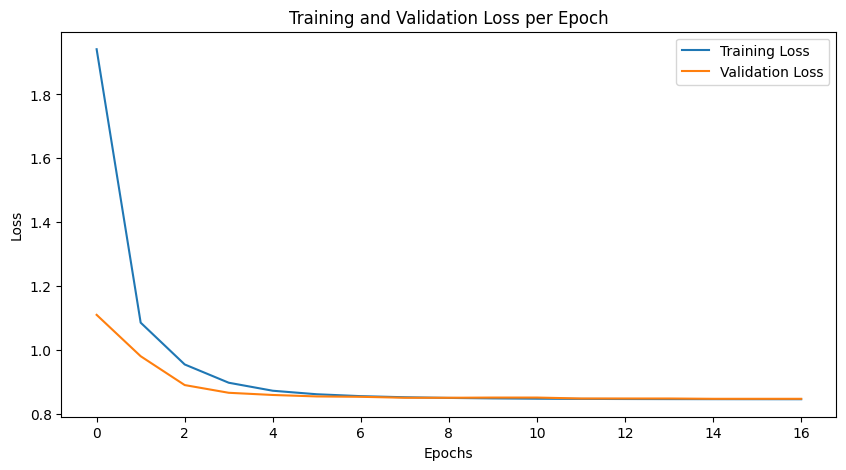

final train loss: 0.8448963020517006 
final validation loss: 0.8462122672513746


In [ ]:
# plotting training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(range(epochs_covered), train_losses, label='Training Loss')
plt.plot(range(epochs_covered), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.show()
print(f"final train loss: {train_losses[-1]} \nfinal validation loss: {val_losses[-1]}")

In [ ]:
def evaluate(dataloader, model):
    # set model to evaluation mode
    model.eval()  
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # print(outputs, targets)
            
            # look into using a different loss function
            loss = nn.MSELoss()(outputs, targets)
            total_loss += loss.item()
            num_batches += 1

    average_loss = total_loss / num_batches
    return average_loss
accuracy = evaluate(test_loader, model)
print(f'Average Loss on test set: {accuracy:.2f}')

Average Loss on test set: 0.85


#### Interpretability

##### All Operations

In [ ]:
ALL_OPERATIONS = [
    "zero",
    "and",
    "not_implies",
    "a",
    "not_implied_by",
    "b",
    "xor",
    "or",
    "not_or",
    "not_xor",
    "not_b",
    "implied_by",
    "not_a",
    "implies",
    "not_and",
    "one",
]

##### Node's Learned State

In [ ]:
# Accessing a specific node's learned state
layer_index = 0
n = model.logic_layers[layer_index].weights.size()[0]
node_index = np.random.randint(n)

# 1770 x 16 matrix
model.logic_layers[layer_index].weights.size()

# gets the weights for the first node of the first logic layer
# note that the weights represent a probability distribution after applying softmax during training
# hence the highest weight corresponds to the chosen logic gate
weights = model.logic_layers[layer_index].weights[node_index]

# gets the index of the highest weight
gate_index = torch.argmax(weights).item()  

logic_operations = [
    "0", "A and B", "not(A implies B)", "A", "not(B implies A)", "B",
    "A xor B", "A or B", "not(A or B)", "not(A xor B)", "not(B)", "B implies A",
    "not(A)", "A implies B", "not(A and B)", "1"
]

#selected_gate = ALL_OPERATIONS[gate_index] -- from the difflogic code
selected_gate = logic_operations[gate_index] # more legible

print(f"The logic gate used by neuron {node_index} is: {selected_gate}")

The logic gate used by neuron 38 is: A


##### Graphical Representation

In [ ]:
model.logic_layers[layer_index].indices

(tensor([42, 22,  3, 14, 41, 42, 32,  2,  4, 48, 46,  0,  8, 59, 37, 38, 54,  3,
         33, 21, 59, 41, 28, 18, 40,  1, 27,  6, 21, 50, 16, 45, 38, 13, 43, 18,
         30, 39,  9, 31, 58,  5, 40, 11, 34, 23, 32, 35, 49, 47, 23, 14,  0,  9,
         16, 50, 31, 15, 20, 10], device='cuda:0'),
 tensor([11, 55, 39, 43, 35, 44, 20, 29, 56, 36, 25, 57, 58, 51, 24, 52, 29, 52,
         19, 27, 37, 19,  4, 44, 22, 48, 30, 34, 36, 53,  1, 15, 10, 26, 12, 24,
          6, 55, 13,  8, 53, 46, 45, 57,  2, 51, 54,  5, 56, 47, 17, 49, 25, 26,
         12, 28,  7, 17, 33,  7], device='cuda:0'))

In [ ]:
#!pip install networkx matplotlib
# https://pyvis.readthedocs.io/en/latest/tutorial.html
#!pip install pyvis
#!pip install pyinstaller

In [ ]:
from pyvis.network import Network
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Logic operations for display
logic_operations = [
    "0", "A∧B", "¬(A⇒B)", "A", "¬(B⇒A)", "B",
    "A⊕B", "A∨B", "¬(A∨B)", "¬(A⊕B)", "¬B", "B⇒A",
    "¬A", "A⇒B", "¬(A∧B)", "1"
]

# Select a layer to visualize
layer_index = 0
logic_layer = model.logic_layers[layer_index]

# Create a directed graph
G = nx.DiGraph()

# Retrieve the connections 
input_indices = logic_layer.indices[0]  # Indices of the first inputs for each logic gate
output_indices = logic_layer.indices[1]  # Indices of the second inputs for each logic gate

# Iterate through each output neuron to get its input connections and determine the logic gate
for output_neuron in range(logic_layer.weights.size()[0]):
    a_idx = input_indices[output_neuron].item()  # Index of the first input neuron
    b_idx = output_indices[output_neuron].item()  # Index of the second input neuron
    gate_idx = torch.argmax(logic_layer.weights[output_neuron]).item()  # Most probable gate index
    gate_label = logic_operations[gate_idx]  # Get the label of the gate

    # Add nodes and edges to the graph
    G.add_node(a_idx, label=f"Node {a_idx}")
    G.add_node(b_idx, label=f"Node {b_idx}")
    G.add_node(output_neuron, label=f"{gate_label}")
    G.add_edge(a_idx, output_neuron, label=gate_label)
    G.add_edge(b_idx, output_neuron, label=gate_label)

# Create a PyVis network from the NetworkX graph
nt = Network("500px", "1000px", notebook=True)
nt.from_nx(G)
nt.show_buttons(filter_=['physics'])  # This allows you to interactively adjust the physics of the network

# Save and display the interactive graph
nt.show("network.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


In [ ]:
#get_learned_logic_gate(model, 1, 1) #-- no attributes layers
model.state_dict()

OrderedDict([('logic_layers.0.weights',
              tensor([[ 2.3354, -0.3403,  1.0290,  ...,  1.3537, -0.8766, -2.3404],
                      [ 3.7262,  1.4515, -3.0142,  ...,  0.0106, -0.4072, -2.6123],
                      [ 3.0610, -1.0435,  3.0191,  ..., -1.0933, -3.6434, -2.9158],
                      ...,
                      [ 2.0858,  0.2190,  3.8291,  ..., -0.5785, -0.9261, -2.3194],
                      [ 2.4754, -0.3252,  0.3983,  ..., -0.3223, -1.4271, -2.4562],
                      [ 2.0502,  0.1185,  0.2175,  ...,  1.4394,  0.0225, -1.7731]],
                     device='cuda:0'))])

#### DiffLogic -> Logic Network

In [ ]:
def zero(a, b):
    return np.zeros_like(a)

def logical_and(a, b):
    return np.logical_and(a, b)

def not_implies(a, b):
    return np.logical_and(a, np.logical_not(b))

def identity_a(a, b):
    return a

def not_implied_by(a, b):
    return np.logical_and(b, np.logical_not(a))

def identity_b(a, b):
    return b

def logical_xor(a, b):
    return np.logical_xor(a, b)

def logical_or(a, b):
    return np.logical_or(a, b)

def not_or(a, b):
    return np.logical_not(np.logical_or(a, b))

def not_xor(a, b):
    return np.logical_not(np.logical_xor(a, b))

def not_b(a, b):
    return np.logical_not(b)

def implied_by(a, b):
    return np.logical_or(np.logical_not(b), a)

def not_a(a, b):
    return np.logical_not(a)

def implies(a, b):
    return np.logical_or(np.logical_not(a), b)

def not_and(a, b):
    return np.logical_not(np.logical_and(a, b))

def one(a, b):
    return np.ones_like(a)

logic_gates = [zero, logical_and, not_implies, identity_a, not_implied_by, identity_b,
               logical_xor, logical_or, not_or, not_xor, not_b, implied_by, not_a,
               implies, not_and, one]

In [ ]:
import torch
import numpy as np

layer_index = 0
logic_layer = model.logic_layers[layer_index]

neuron_gates = []
connections = {}

input_indices = logic_layer.indices[0].cpu().numpy()  # First input indices
output_indices = logic_layer.indices[1].cpu().numpy()  # Second input indices

for output_neuron in range(logic_layer.weights.size()[0]):
    gate_idx = torch.argmax(logic_layer.weights[output_neuron]).item()
    neuron_gates.append(gate_idx)
    connections[output_neuron] = (input_indices[output_neuron], output_indices[output_neuron])

In [ ]:
# forward using DiffLogic and eval using LogicNetwork
class LogicNeuron:
    def __init__(self, gate_idx):
        self.operation = logic_gates[gate_idx]

    def forward(self, input_a, input_b):
        return self.operation(input_a, input_b)

class LogicNetwork:
    def __init__(self, neuron_gates, connections):
        self.neurons = {i: LogicNeuron(gate) for i, gate in enumerate(neuron_gates)}
        self.connections = connections

    def forward(self, inputs):
        outputs = {}
        for neuron_id in self.connections:
            input_a_idx, input_b_idx = self.connections[neuron_id]
            input_a = inputs[input_a_idx]
            input_b = inputs[input_b_idx]
            outputs[neuron_id] = self.neurons[neuron_id].forward(input_a, input_b)
        return outputs

In [ ]:
# Example input, currently just random numbers.
inputs = np.random.choice([True, False], size=(max(input_indices.max(), output_indices.max()) + 1))

# Initialize the network
network = LogicNetwork(neuron_gates, connections)

# Execute the network
outputs = network.forward(inputs)
print(outputs)

{0: True, 1: True, 2: True, 3: True, 4: True, 5: True, 6: False, 7: True, 8: False, 9: array(True), 10: array(True), 11: False, 12: True, 13: False, 14: array(True), 15: True, 16: True, 17: True, 18: False, 19: True, 20: True, 21: True, 22: False, 23: False, 24: True, 25: array(True), 26: True, 27: True, 28: True, 29: True, 30: True, 31: True, 32: True, 33: array(True), 34: True, 35: True, 36: True, 37: True, 38: True, 39: False, 40: True, 41: False, 42: True, 43: False, 44: array(True), 45: True, 46: False, 47: False, 48: False, 49: array(True), 50: True, 51: array(True), 52: array(True), 53: True, 54: True, 55: True, 56: True, 57: True, 58: False, 59: True}


#### Verilog File Creation

In [ ]:
import torch
import numpy as np

# Logic gate to Verilog expression mapping
logic_gate_verilog = {
    "0": "1'b0",
    "A∧B": "{a} & {b}",
    "¬(A⇒B)": "{a} & ~{b}",
    "A": "{a}",
    "¬(B⇒A)": "{b} & ~{a}",
    "B": "{b}",
    "A⊕B": "{a} ^ {b}",
    "A∨B": "{a} | {b}",
    "¬(A∨B)": "~({a} | {b})",
    "¬(A⊕B)": "~({a} ^ {b})",
    "¬B": "~{b}",
    "B⇒A": "~{b} | {a}",
    "¬A": "~{a}",
    "A⇒B": "~{a} | {b}",
    "¬(A∧B)": "~({a} & {b})",
    "1": "1'b1"
}

# Assuming `model` and `logic_layer` have already been defined and populated
layer_index = 0
logic_layer = model.logic_layers[layer_index]

input_indices = logic_layer.indices[0].cpu().numpy()  # First input indices
output_indices = logic_layer.indices[1].cpu().numpy()  # Second input indices
neuron_gates = [torch.argmax(logic_layer.weights[neuron]).item() for neuron in range(logic_layer.weights.size()[0])]
connections = {i: (input_indices[i], output_indices[i]) for i in range(len(neuron_gates))}

def generate_verilog(neuron_gates, connections, filename="logic_network.v"):
    with open(filename, 'w') as file:
        file.write("module logic_network(\n")
        file.write("    input wire [{}:0] inputs,\n".format(max(max(connections.keys()), max(max(con) for con in connections.values()))))
        file.write("    output wire [{}:0] outputs\n".format(len(neuron_gates) - 1))
        file.write(");\n\n")

        # Declare wires for internal connections
        for neuron_id in connections:
            a_idx, b_idx = connections[neuron_id]
            gate = logic_gate_verilog[logic_operations[neuron_gates[neuron_id]]].format(a=f"inputs[{a_idx}]", b=f"inputs[{b_idx}]")
            file.write(f"    assign outputs[{neuron_id}] = {gate};\n")

        file.write("endmodule\n")

# Generate Verilog file
generate_verilog(neuron_gates, connections)

#### Verilog File Reading and Visualiazation

In [ ]:
#!pip install pyverilog graphviz

In [ ]:
import pyverilog.vparser.parser as parser
from graphviz import Digraph

def create_schematic_from_verilog(file_path):
    ast, _ = parser.parse([file_path])
    dot = Digraph(comment='Verilog Schematic')

    # Function to recursively visit nodes and create edges
    def visit(node, parent=None):
        if node is None:
            return
        if hasattr(node, 'name'):
            dot.node(node.name, label=str(node.__class__).split('.')[-1].strip("'>"))
            if parent:
                dot.edge(parent.name, node.name)
        
        if hasattr(node, 'children'):
            for child in node.children():
                visit(child, parent=node)

    visit(ast)
    dot.render('output/schematic', view=True)  # Saves and opens the schematic diagram

# Example usage
create_schematic_from_verilog('logic_network.v')

Generating LALR tables


FileNotFoundError: [Errno 2] No such file or directory: 'iverilog'

In [ ]:
# Olivia's thought on how "strong" a certain connection is. aka why one gate was chosen over another one (based on probability, but what was second probability, etc)
# e.g. 80% AND gate, 10% NAND gate, 5% OR gate, ...
# Ensembl model
# if we changed a certain ouput, what would happen?

#### Model Saving and Loading

In [ ]:
# names the model and saves to saved_model folder
filename = '6-10-2024.pth'
current_path = os.getcwd() + "/saved_model/"
path = os.path.join(current_path, filename)
torch.save(model.state_dict(), path)

In [ ]:
# you CANNOT load using 
# model.load_state_dict(PATH)
dict_obj = torch.load(path)
loaded_model = model.load_state_dict(dict_obj)
loaded_model

<All keys matched successfully>